In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset, clean_dataset_bh

In [2]:
raw_df1 = pd.read_csv('Huawei_Daily_4G_2.csv')
df1 = clean_dataset(raw_df1)

raw_df2 = pd.read_csv('Huawei_BH_4G_2.csv')
df2 = clean_dataset_bh(raw_df2)

C:\Users\hkizamou\AppData\Local\Temp\ipykernel_6940\2009245305.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df1 = pd.read_csv('Huawei_Daily_4G_2.csv')
C:\Users\hkizamou\AppData\Local\Temp\ipykernel_6940\2009245305.py:4: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df2 = pd.read_csv('Huawei_BH_4G_2.csv')


### Merging the datasets

In [3]:
import pandas as pd
from pandas.api.types import is_numeric_dtype, is_bool_dtype

# Exclude these prefixes
DROP_PREFIXES = ("CSSR_wo_VoLTE", "DRC_wo_VoLTE")

def _kpi_cols_no_cssr_drc(df: pd.DataFrame):
    """Numeric (non-bool) KPI columns, excluding *_missing and CSSR/DRC."""
    cols = []
    for c in df.columns:
        if c.endswith("_missing"):
            continue
        if any(c.startswith(p) for p in DROP_PREFIXES):
            continue
        if is_numeric_dtype(df[c]) and not is_bool_dtype(df[c]):
            cols.append(c)
    return cols

def build_overlap_df(
    daily_df: pd.DataFrame,
    bh_df: pd.DataFrame,
    keys=("Date","Cell_Name","LocalCell_Id"),
    keep_time_cols=("Hour", "Time"),
):
    d1 = daily_df.copy()
    d2 = bh_df.copy()

    # Normalize Date
    d1["Date"] = pd.to_datetime(d1["Date"]).dt.normalize()
    d2["Date"] = pd.to_datetime(d2["Date"]).dt.normalize()

    # KPI columns
    daily_kpis = _kpi_cols_no_cssr_drc(d1)
    bh_kpis    = _kpi_cols_no_cssr_drc(d2)

    # Drop Hour/Time from Daily
    d1 = d1.drop(columns=[c for c in keep_time_cols if c in d1.columns], errors="ignore")

    # Non-KPI/meta from Daily
    non_kpi_daily = [
        c for c in d1.columns
        if c not in daily_kpis
        and not c.endswith("_missing")
        and not any(c.startswith(p) for p in DROP_PREFIXES)
    ]
    # Ensure keys included
    for k in keys:
        if k not in non_kpi_daily:
            non_kpi_daily.insert(0, k)

    # Minimal BH meta to keep
    bh_meta = [k for k in keys if k in d2.columns]
    for col in keep_time_cols:
        if col in d2.columns and col not in bh_meta:
            bh_meta.append(col)

    # Subsets
    daily_subset = d1[non_kpi_daily + daily_kpis]
    bh_subset    = d2[bh_meta + bh_kpis]

    # Merge
    df = pd.merge(
        daily_subset, bh_subset,
        on=list(keys), how="inner",
        suffixes=("_daily", "_bh")
    )

    # Safety: drop any CSSR/DRC columns that might still be around
    drop_cols = [c for c in df.columns if any(c.startswith(p) for p in DROP_PREFIXES)]
    if drop_cols:
        df = df.drop(columns=drop_cols, errors="ignore")

    # Deduplicate columns
    df = df.loc[:, ~df.columns.duplicated()]

    # Enforce single Hour/Time (keep first occurrence, place after keys)
    hour_cols = [c for c in df.columns if c == "Hour"]
    if len(hour_cols) > 1:
        first_idx = df.columns.get_loc("Hour")
        hour_series = df.iloc[:, first_idx].astype("int32")
        df = df.drop(columns=hour_cols)
        df.insert(len(keys), "Hour", hour_series.values)

    time_cols = [c for c in df.columns if c == "Time"]
    if len(time_cols) > 1:
        first_idx = df.columns.get_loc("Time")
        time_series = df.iloc[:, first_idx]
        df = df.drop(columns=time_cols)
        df.insert(len(keys) + (1 if "Hour" in df.columns else 0), "Time", time_series.values)

    # Order nicely
    time_cols_out = [c for c in keep_time_cols if c in df.columns]
    daily_meta_out = [c for c in non_kpi_daily if c not in keys]
    daily_kpis_out = [f"{c}_daily" if f"{c}_daily" in df.columns else c for c in daily_kpis]
    bh_kpis_out    = [f"{c}_bh"    if f"{c}_bh"    in df.columns else c for c in bh_kpis]

    ordered = list(keys) + time_cols_out + daily_meta_out + daily_kpis_out + bh_kpis_out
    leftovers = [c for c in df.columns if c not in set(ordered)]
    df = df[ordered + leftovers]

    meta = {
        "keys": list(keys),
        "time_cols": time_cols_out,
        "daily_kpis": daily_kpis,
        "bh_kpis": bh_kpis,
        "n_rows": len(df),
        "n_cols": df.shape[1],
        "dropped_prefixes": DROP_PREFIXES,
    }

    if df.columns[-1] == "Hour":
        df = df.iloc[:, :-1]

    return df, meta

# --------
df, meta = build_overlap_df(df1, df2, keys=("Date","Cell_Name","LocalCell_Id"))
print(meta)

# Sanity check: show remaining BH columns
print("Remaining BH columns:", [c for c in df.columns if c.endswith("_bh")])

df.describe()

{'keys': ['Date', 'Cell_Name', 'LocalCell_Id'], 'time_cols': ['Hour', 'Time'], 'daily_kpis': ['Avg_DL_User_Thrput_kbps', 'UL_Traffic_Volume_GBytes', 'Avg_UL_User_Thrput_kbps', 'DL_Traffic_Volume_GBytes', 'Avg_DL_Traffic_Active_User', 'Avg_UL_Traffic_Active_User', 'Avg_DL_PRB_Usage', 'Avg_UL_PRB_Usage', 'Avg_Traffic_User'], 'bh_kpis': ['Avg_DL_User_Thrput_kbps', 'UL_Traffic_Volume_GBytes', 'Avg_UL_User_Thrput_kbps', 'DL_Traffic_Volume_GBytes', 'Avg_DL_Traffic_Active_User', 'Avg_UL_Traffic_Active_User', 'Avg_DL_PRB_Usage', 'Avg_UL_PRB_Usage', 'Avg_Traffic_User', 'Hour'], 'n_rows': 405199, 'n_cols': 29, 'dropped_prefixes': ('CSSR_wo_VoLTE', 'DRC_wo_VoLTE')}
Remaining BH columns: ['Avg_DL_User_Thrput_kbps_bh', 'UL_Traffic_Volume_GBytes_bh', 'Avg_UL_User_Thrput_kbps_bh', 'DL_Traffic_Volume_GBytes_bh', 'Avg_DL_Traffic_Active_User_bh', 'Avg_UL_Traffic_Active_User_bh', 'Avg_DL_PRB_Usage_bh', 'Avg_UL_PRB_Usage_bh', 'Avg_Traffic_User_bh']


,Date,Hour,Avg_DL_User_Thrput_kbps_daily,UL_Traffic_Volume_GBytes_daily,Avg_UL_User_Thrput_kbps_daily,DL_Traffic_Volume_GBytes_daily,Avg_DL_Traffic_Active_User_daily,Avg_UL_Traffic_Active_User_daily,Avg_DL_PRB_Usage_daily,Avg_UL_PRB_Usage_daily,Avg_Traffic_User_daily,Avg_DL_User_Thrput_kbps_bh,UL_Traffic_Volume_GBytes_bh,Avg_UL_User_Thrput_kbps_bh,DL_Traffic_Volume_GBytes_bh,Avg_DL_Traffic_Active_User_bh,Avg_UL_Traffic_Active_User_bh,Avg_DL_PRB_Usage_bh,Avg_UL_PRB_Usage_bh,Avg_Traffic_User_bh
count,405199,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000,405199.000000
mean,2025-07-26 23:55:39.221468672,19.440292,21226.104346,7.771906,3838.675611,67.013248,1.268580,0.941014,23.608161,13.193778,19.534967,16284.986969,0.673341,3786.706118,5.689823,4.142665,2.347594,49.187351,21.205151,37.775712
min,2025-07-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-07-19 00:00:00,20.000000,12803.292300,2.117400,2803.535600,18.430950,0.165100,0.241950,9.912900,7.664500,4.828500,7308.744650,0.200200,2299.998600,2.101500,0.513400,0.618600,24.465900,11.104050,10.432950
50%,2025-07-27 00:00:00,21.000000,19862.712300,5.305400,3726.808000,46.690500,0.402200,0.548600,18.870900,10.722300,12.023000,13846.516600,0.482200,3302.575700,4.673000,1.182300,1.339500,46.153900,17.938200,24.787400
75%,2025-08-04 00:00:00,22.000000,28189.655100,10.843300,4661.633000,95.909500,0.891200,1.076900,32.127850,16.249250,26.534900,22388.503500,0.930300,4621.872100,8.195250,2.723500,2.452900,73.271850,27.543750,50.500500
max,2025-08-11 00:00:00,23.000000,124337.279100,258.021600,38428.280200,774.395100,143.496100,138.179800,99.843200,94.267800,413.162700,181168.894200,14.999500,112587.709900,54.246600,400.072700,412.820000,99.986400,99.656600,805.472500
std,NaN,4.615740,11558.103957,8.197514,1601.292311,65.194543,4.391089,2.337456,18.146042,8.197219,22.871550,12080.164668,0.681177,2460.129296,4.542250,12.033105,7.078433,28.593323,13.562172,43.466793


In [4]:
# --- Configure your keys and a few KPIs
KEYS = ["Date","Cell_Name","LocalCell_Id"]
DAILY_KPIS = [
    "Avg_DL_PRB_Usage", "Avg_UL_PRB_Usage",
    "Avg_DL_User_Thrput_kbps", "Avg_UL_User_Thrput_kbps",
    "DL_Traffic_Volume_GBytes", "UL_Traffic_Volume_GBytes",
    "Avg_DL_Traffic_Active_User", "Avg_UL_Traffic_Active_User"
]
BH_KPIS = DAILY_KPIS  # same names on BH side

def validate_merged(df, df_daily, df_bh, keys=KEYS, daily_kpis=DAILY_KPIS, bh_kpis=BH_KPIS, sample_n=5):
    rep = {}

    # 0) Columns exist?
    rep["has_keys"] = all(k in df.columns for k in keys)
    rep["has_hour"] = "Hour" in df.columns
    rep["rows"] = len(df)
    rep["cols"] = df.shape[1]

    # 1) Overlap size vs BH/Daily overlap (should match inner-join size)
    d1 = df_daily[keys].drop_duplicates()
    d2 = df_bh[keys].drop_duplicates()
    overlap_estimate = len(d1.merge(d2, on=keys, how="inner"))
    rep["expected_overlap_rows_unique_keys"] = overlap_estimate
    rep["observed_unique_keys_in_df"] = len(df[keys].drop_duplicates())

    # 2) Duplicates check (one BH per cell/day expected -> usually 1 row per keys)
    rep["duplicate_key_rows"] = int(df.duplicated(subset=keys).sum())

    # 3) Nulls in critical columns
    nulls = df[keys + ["Hour"]].isna().sum().to_dict()
    rep["nulls_in_keys_hour"] = nulls

    # 4) Hour sanity
    if "Hour" in df.columns:
        rep["hour_min_max"] = (int(df["Hour"].min()), int(df["Hour"].max()))

    # 5) Quick distribution sanity for a few KPI pairs
    for k in daily_kpis:
        kd = f"{k}_daily" if f"{k}_daily" in df.columns else None
        kb = f"{k}_bh"    if f"{k}_bh" in df.columns else None
        if kd and kb:
            rep[f"{k}_daily_min_max"] = (float(df[kd].min()), float(df[kd].max()))
            rep[f"{k}_bh_min_max"]    = (float(df[kb].min()), float(df[kb].max()))
            rep[f"{k}_corr_daily_bh"] = float(df[[kd, kb]].corr().iloc[0,1])

    # 6) Spot-check: for a random sample, compare merged values with the sources
    sample = df.sample(min(sample_n, len(df)), random_state=42)[keys]
    chk = sample.merge(df, on=keys, how="left")
    chk_d1 = sample.merge(df_daily, on=keys, how="left")
    chk_bh = sample.merge(df_bh, on=keys, how="left")

    spot = []
    for k in daily_kpis:
        kd = f"{k}_daily" if f"{k}_daily" in df.columns else None
        if kd and k in chk_d1.columns:
            same = np.allclose(chk[kd].astype(float).values,
                               chk_d1[k].astype(float).values, equal_nan=True)
            spot.append((f"{k}: df vs Daily", bool(same)))
    for k in bh_kpis:
        kb = f"{k}_bh" if f"{k}_bh" in df.columns else None
        if kb and k in chk_bh.columns:
            same = np.allclose(chk[kb].astype(float).values,
                               chk_bh[k].astype(float).values, equal_nan=True)
            spot.append((f"{k}: df vs BH", bool(same)))

    rep["spot_checks"] = spot

    # 7) Expectation checks:
    exp = {}
    for k in ["Avg_DL_PRB_Usage","Avg_UL_PRB_Usage"]:
        kd = f"{k}_daily"; kb = f"{k}_bh"
        if kd in df.columns and kb in df.columns:
            share_bh_ge_daily = float((df[kb] >= df[kd]).mean())
            exp[f"{k}_BH_ge_Daily_share"] = share_bh_ge_daily  # e.g., expect > 0.6 or so
    rep["expectations"] = exp

    # Pretty print
    print("\n=== MERGE VALIDATION REPORT ===")
    for k,v in rep.items():
        print(f"{k}: {v}")
    print("===============================")
    return rep

# -----
report = validate_merged(df, df1, df2)


=== MERGE VALIDATION REPORT ===
has_keys: True
has_hour: True
rows: 405199
cols: 28
expected_overlap_rows_unique_keys: 405199
observed_unique_keys_in_df: 405199
duplicate_key_rows: 0
nulls_in_keys_hour: {'Date': 0, 'Cell_Name': 0, 'LocalCell_Id': 0, 'Hour': 0}
hour_min_max: (0, 23)
Avg_DL_PRB_Usage_daily_min_max: (0.0, 99.8432)
Avg_DL_PRB_Usage_bh_min_max: (0.0, 99.9864)
Avg_DL_PRB_Usage_corr_daily_bh: 0.8634499021192618
Avg_UL_PRB_Usage_daily_min_max: (0.0, 94.2678)
Avg_UL_PRB_Usage_bh_min_max: (0.0, 99.6566)
Avg_UL_PRB_Usage_corr_daily_bh: 0.9098859581012453
Avg_DL_User_Thrput_kbps_daily_min_max: (0.0, 124337.2791)
Avg_DL_User_Thrput_kbps_bh_min_max: (0.0, 181168.8942)
Avg_DL_User_Thrput_kbps_corr_daily_bh: 0.905371380065327
Avg_UL_User_Thrput_kbps_daily_min_max: (0.0, 38428.2802)
Avg_UL_User_Thrput_kbps_bh_min_max: (0.0, 112587.7099)
Avg_UL_User_Thrput_kbps_corr_daily_bh: 0.6813724403624984
DL_Traffic_Volume_GBytes_daily_min_max: (0.0, 774.3951)
DL_Traffic_Volume_GBytes_bh_min_max:

In [5]:
# --- features: ALL daily KPIs except CSSR/DRC ---
feature_cols = [
    c for c in df.columns
    if c.endswith("_daily")
    and not c.startswith("CSSR_wo_VoLTE")
    and not c.startswith("DRC_wo_VoLTE")
]

# --- targets: ONLY the 9 DL BH KPIs ---
target_cols = [
    "Avg_DL_User_Thrput_kbps_bh",
    "Avg_UL_User_Thrput_kbps_bh",
    "DL_Traffic_Volume_GBytes_bh",
    "UL_Traffic_Volume_GBytes_bh",
    "Avg_DL_Traffic_Active_User_bh",
    "Avg_UL_Traffic_Active_User_bh",
    "Avg_DL_PRB_Usage_bh",
    "Avg_UL_PRB_Usage_bh",
    "Avg_Traffic_User_bh",
]

assert len(feature_cols) > 0, "No features found."
assert len(target_cols) == 9, f"Expected 9 targets, got {len(target_cols)}"
print("Features (#):", len(feature_cols))
print("Targets:", target_cols)

Features (#): 9
Targets: ['Avg_DL_User_Thrput_kbps_bh', 'Avg_UL_User_Thrput_kbps_bh', 'DL_Traffic_Volume_GBytes_bh', 'UL_Traffic_Volume_GBytes_bh', 'Avg_DL_Traffic_Active_User_bh', 'Avg_UL_Traffic_Active_User_bh', 'Avg_DL_PRB_Usage_bh', 'Avg_UL_PRB_Usage_bh', 'Avg_Traffic_User_bh']


In [6]:
# ------------------ time-based split ------------------
VAL_FRAC = 0.20  # last 20% of time as validation

dates = pd.to_datetime(df["Date"])
cutoff = dates.quantile(1 - VAL_FRAC)  # last VAL_FRAC of time is validation

train_mask = dates <= cutoff
val_mask   = dates >  cutoff

# Features
X_train = df.loc[train_mask, feature_cols].astype("float32")
X_val   = df.loc[val_mask,   feature_cols].astype("float32")

# Targets
y_train_df = df.loc[train_mask, target_cols].astype("float32")
y_val_df   = df.loc[val_mask,   target_cols].astype("float32")

# Simple imputation: fill missing values with column medians
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_val   = X_val.fillna(X_val.median(numeric_only=True))

print("Train shape:", X_train.shape, y_train_df.shape)
print("Val shape:",   X_val.shape,   y_val_df.shape)
print("Cutoff date:", cutoff.date())

Train shape: (326828, 9) (326828, 9)
Val shape: (78371, 9) (78371, 9)
Cutoff date: 2025-08-05


In [7]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------ LightGBM config ------------------
lgb_params = dict(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="regression",
)

fitted = {}
metrics_mae, metrics_rmse, metrics_r2 = {}, {}, {}

# ------------------ Train per target ------------------
for i, col in enumerate(target_cols):
    ytr = y_train_df[col].values
    yva = y_val_df[col].values

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_train, ytr,
        eval_set=[(X_val, yva)],
        eval_metric="l2",
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(100)
        ]
    )
    fitted[col] = model

    # validation predictions
    yhat = model.predict(X_val)
    metrics_mae[col]  = float(mean_absolute_error(yva, yhat))
    metrics_rmse[col] = float(np.sqrt(mean_squared_error(yva, yhat)))
    metrics_r2[col]   = float(r2_score(yva, yhat))

# ------------------ Summary ------------------
print("\n=== Validation (LightGBM, no CSSR/DRC, no UL targets) ===")
print("Mean MAE:", float(np.mean(list(metrics_mae.values()))))
print("Mean RMSE:", float(np.mean(list(metrics_rmse.values()))))
print("Mean R²:", float(np.mean(list(metrics_r2.values()))))
print("Sample MAE:", dict(list(metrics_mae.items())[:5]))
print("Sample RMSE:", dict(list(metrics_rmse.items())[:5]))
print("Sample R²:", dict(list(metrics_r2.items())[:5]))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 326828, number of used features: 9
[LightGBM] [Info] Start training from score 16336.603785
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 2.20976e+07
[200]	valid_0's l2: 2.18531e+07
[300]	valid_0's l2: 2.17981e+07
[400]	valid_0's l2: 2.17982e+07
Early stopping, best iteration is:
[332]	valid_0's l2: 2.17866e+07
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012174 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 326828, number of used features: 9
[LightGBM] [Info] Start training from score 


=== Top Features for Avg_DL_User_Thrput_kbps_bh ===
Avg_DL_User_Thrput_kbps_daily       3188
DL_Traffic_Volume_GBytes_daily      2709
Avg_UL_User_Thrput_kbps_daily       2542
Avg_DL_PRB_Usage_daily              2520
Avg_Traffic_User_daily              2469
Avg_UL_PRB_Usage_daily              2143
Avg_DL_Traffic_Active_User_daily    1991
UL_Traffic_Volume_GBytes_daily      1835
Avg_UL_Traffic_Active_User_daily    1519
dtype: int32


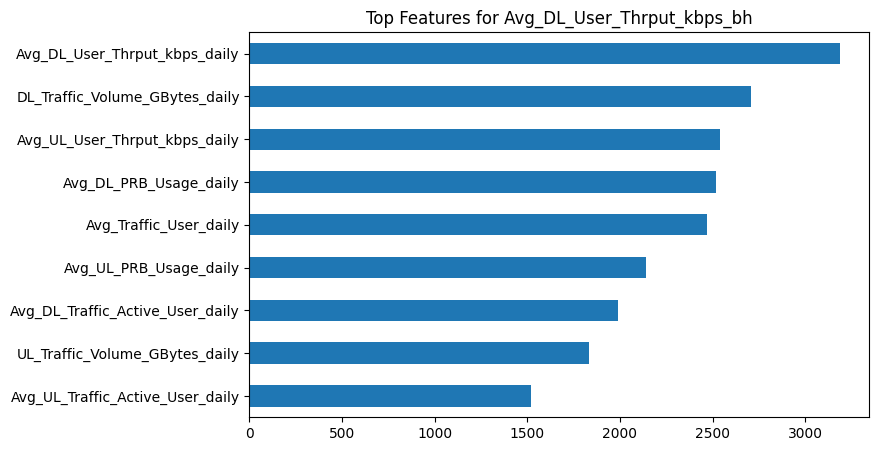


=== Top Features for Avg_UL_User_Thrput_kbps_bh ===
UL_Traffic_Volume_GBytes_daily      1284
Avg_UL_User_Thrput_kbps_daily       1237
Avg_Traffic_User_daily              1234
Avg_DL_User_Thrput_kbps_daily       1134
Avg_UL_PRB_Usage_daily              1039
Avg_UL_Traffic_Active_User_daily    1023
Avg_DL_Traffic_Active_User_daily    1000
Avg_DL_PRB_Usage_daily               845
DL_Traffic_Volume_GBytes_daily       843
dtype: int32


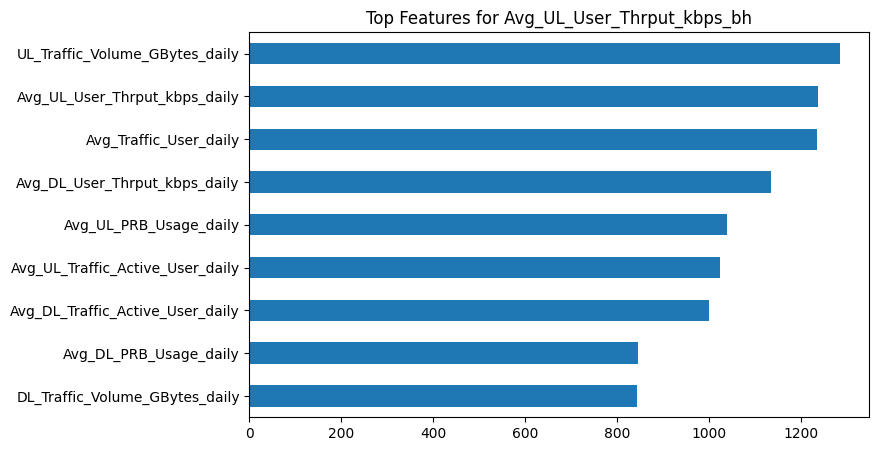


=== Top Features for DL_Traffic_Volume_GBytes_bh ===
Avg_DL_User_Thrput_kbps_daily       15361
DL_Traffic_Volume_GBytes_daily      14790
Avg_UL_User_Thrput_kbps_daily       14692
Avg_Traffic_User_daily              14542
Avg_DL_PRB_Usage_daily              14218
Avg_UL_PRB_Usage_daily              14188
Avg_DL_Traffic_Active_User_daily    13072
UL_Traffic_Volume_GBytes_daily      12773
Avg_UL_Traffic_Active_User_daily    12364
dtype: int32


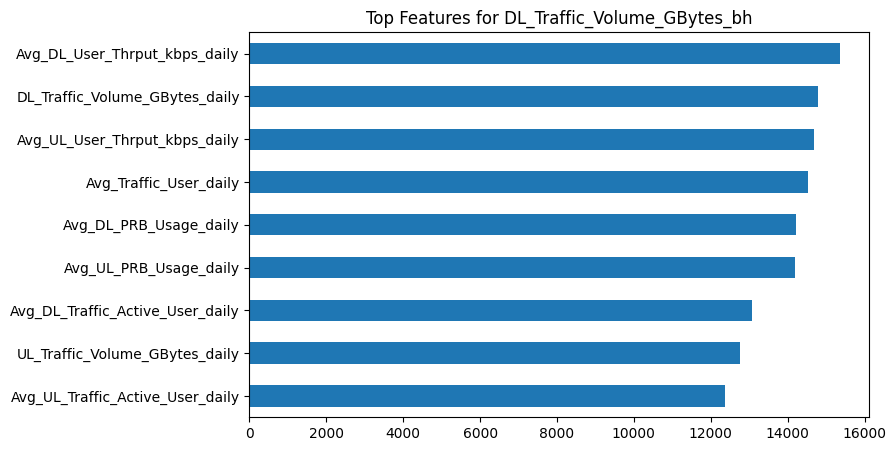


=== Top Features for UL_Traffic_Volume_GBytes_bh ===
UL_Traffic_Volume_GBytes_daily      3081
Avg_DL_PRB_Usage_daily              2889
Avg_UL_User_Thrput_kbps_daily       2569
Avg_DL_Traffic_Active_User_daily    2536
Avg_DL_User_Thrput_kbps_daily       2411
DL_Traffic_Volume_GBytes_daily      2410
Avg_UL_PRB_Usage_daily              2058
Avg_UL_Traffic_Active_User_daily    1960
Avg_Traffic_User_daily              1821
dtype: int32


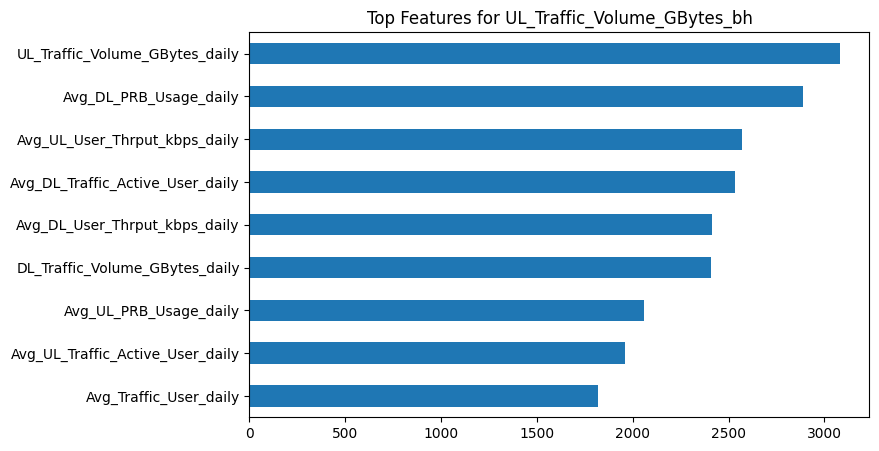


=== Top Features for Avg_DL_Traffic_Active_User_bh ===
Avg_UL_User_Thrput_kbps_daily       5878
DL_Traffic_Volume_GBytes_daily      4161
Avg_DL_User_Thrput_kbps_daily       3804
Avg_DL_PRB_Usage_daily              3780
Avg_DL_Traffic_Active_User_daily    3342
Avg_Traffic_User_daily              2977
Avg_UL_PRB_Usage_daily              2918
UL_Traffic_Volume_GBytes_daily      2781
Avg_UL_Traffic_Active_User_daily    2552
dtype: int32


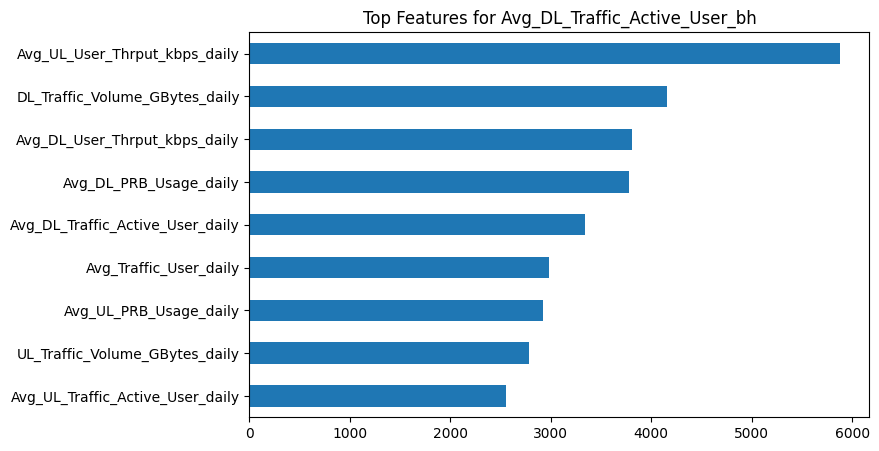


=== Top Features for Avg_UL_Traffic_Active_User_bh ===
Avg_UL_User_Thrput_kbps_daily       639
DL_Traffic_Volume_GBytes_daily      400
Avg_DL_PRB_Usage_daily              389
Avg_UL_Traffic_Active_User_daily    388
Avg_UL_PRB_Usage_daily              331
Avg_DL_User_Thrput_kbps_daily       304
UL_Traffic_Volume_GBytes_daily      218
Avg_Traffic_User_daily              179
Avg_DL_Traffic_Active_User_daily    176
dtype: int32


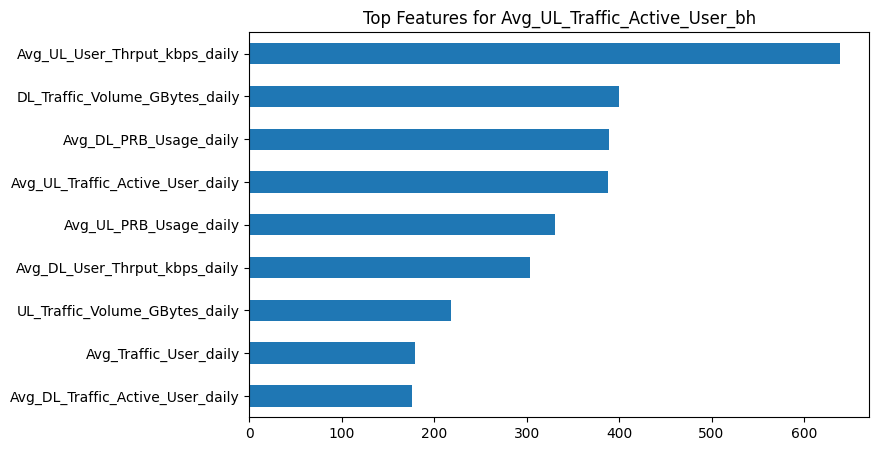


=== Top Features for Avg_DL_PRB_Usage_bh ===
Avg_DL_User_Thrput_kbps_daily       15634
Avg_DL_PRB_Usage_daily              15110
Avg_UL_PRB_Usage_daily              14732
Avg_Traffic_User_daily              14654
DL_Traffic_Volume_GBytes_daily      14207
Avg_UL_User_Thrput_kbps_daily       13766
Avg_DL_Traffic_Active_User_daily    13765
Avg_UL_Traffic_Active_User_daily    12548
UL_Traffic_Volume_GBytes_daily      11584
dtype: int32


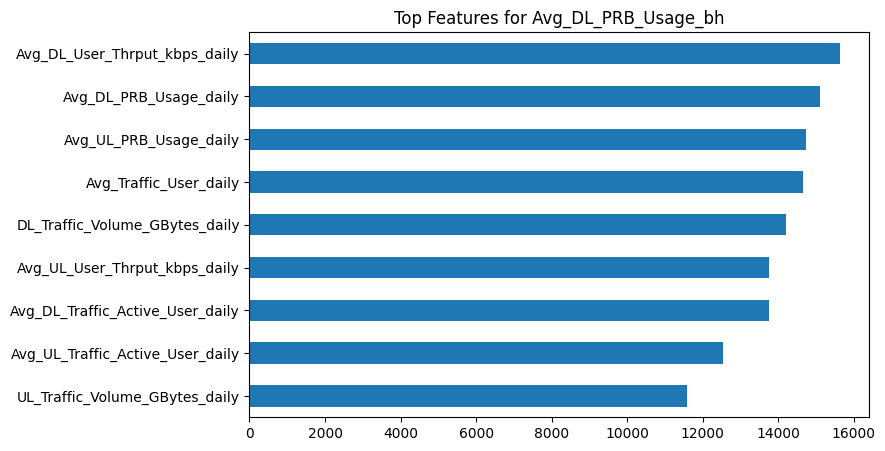


=== Top Features for Avg_UL_PRB_Usage_bh ===
Avg_UL_User_Thrput_kbps_daily       15631
Avg_UL_PRB_Usage_daily              15190
Avg_DL_User_Thrput_kbps_daily       14072
Avg_DL_PRB_Usage_daily              13956
Avg_Traffic_User_daily              13889
UL_Traffic_Volume_GBytes_daily      13683
DL_Traffic_Volume_GBytes_daily      12740
Avg_DL_Traffic_Active_User_daily    12554
Avg_UL_Traffic_Active_User_daily    12269
dtype: int32


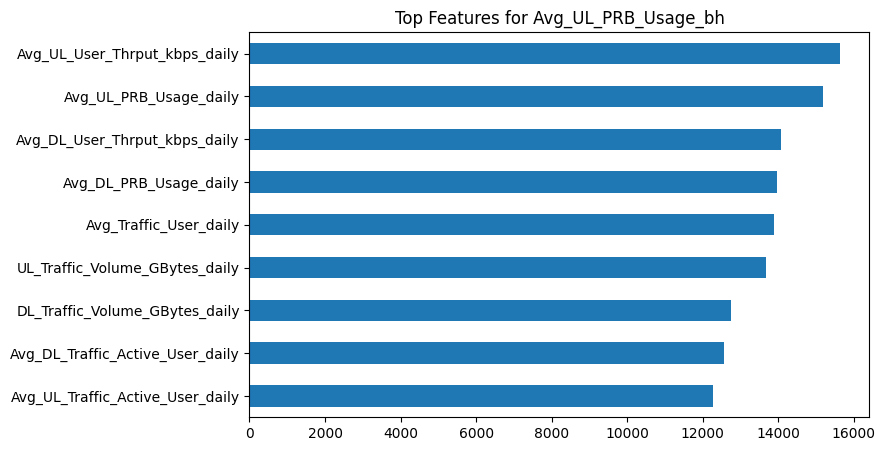


=== Top Features for Avg_Traffic_User_bh ===
Avg_UL_User_Thrput_kbps_daily       15159
Avg_Traffic_User_daily              12200
Avg_DL_PRB_Usage_daily              11761
Avg_DL_User_Thrput_kbps_daily       11464
DL_Traffic_Volume_GBytes_daily      11210
Avg_UL_PRB_Usage_daily              11137
Avg_DL_Traffic_Active_User_daily     9780
Avg_UL_Traffic_Active_User_daily     9436
UL_Traffic_Volume_GBytes_daily       8905
dtype: int32


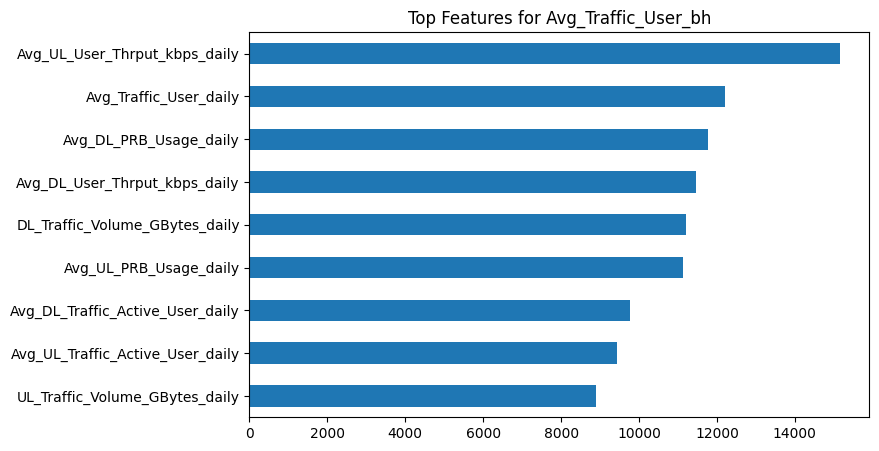

In [8]:
import matplotlib.pyplot as plt

# ------------------ Feature Importance per Target ------------------
for col in target_cols:
    model = fitted[col]
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

    print(f"\n=== Top Features for {col} ===")
    print(feat_imp.head(10))

    # Optional: plot
    plt.figure(figsize=(8,5))
    feat_imp.head(15).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Top Features for {col}")
    plt.show()

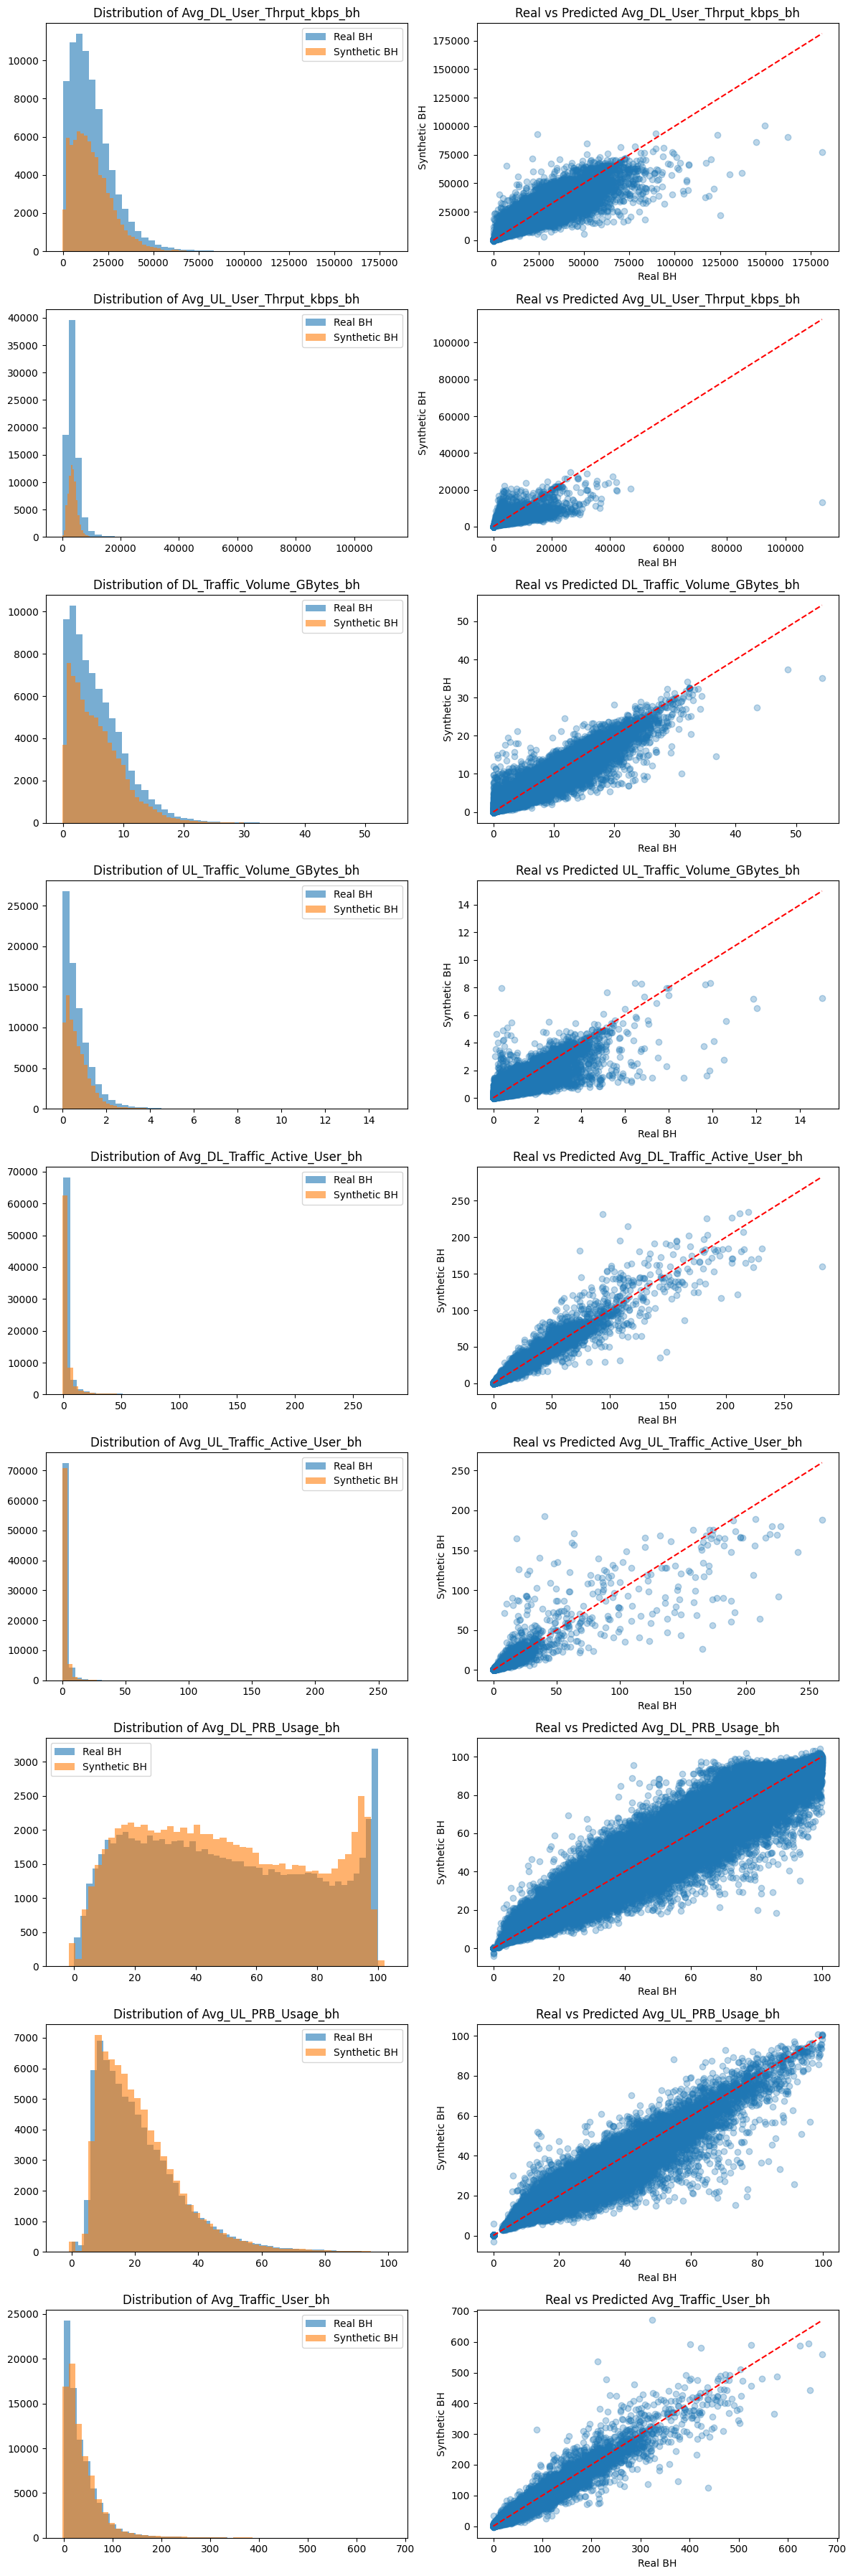

In [9]:
# Plot distributions and scatter plots for each target
fig, axes = plt.subplots(len(target_cols), 2, figsize=(12, 4*len(target_cols)))

for i, col in enumerate(target_cols):
    y_true = y_val_df[col].values
    y_pred = fitted[col].predict(X_val)
    
    # Histogram comparison: real vs synthetic BH
    axes[i,0].hist(y_true, bins=50, alpha=0.6, label="Real BH")
    axes[i,0].hist(y_pred, bins=50, alpha=0.6, label="Synthetic BH")
    axes[i,0].set_title(f"Distribution of {col}")
    axes[i,0].legend()
    
    # Scatter plot: one-to-one line
    axes[i,1].scatter(y_true, y_pred, alpha=0.3)
    axes[i,1].plot([y_true.min(), y_true.max()],
                   [y_true.min(), y_true.max()], 'r--')
    axes[i,1].set_title(f"Real vs Predicted {col}")
    axes[i,1].set_xlabel("Real BH")
    axes[i,1].set_ylabel("Synthetic BH")

plt.tight_layout()
plt.show()

In [10]:
# ------------------ LightGBM config ------------------
lgb_params = dict(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="tweedie",
    tweedie_variance_power=1.2
)

fitted = {}
metrics_mae, metrics_rmse, metrics_r2 = {}, {}, {}

# ------------------ Train per target ------------------
for i, col in enumerate(target_cols):
    ytr = y_train_df[col].values
    yva = y_val_df[col].values

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_train, ytr,
        eval_set=[(X_val, yva)],
        eval_metric="l2",
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(100)
        ]
    )
    fitted[col] = model

    # validation predictions
    yhat = model.predict(X_val)
    metrics_mae[col]  = float(mean_absolute_error(yva, yhat))
    metrics_rmse[col] = float(np.sqrt(mean_squared_error(yva, yhat)))
    metrics_r2[col]   = float(r2_score(yva, yhat))

# ------------------ Summary ------------------
print("\n=== Validation (LightGBM, Tweedie, no CSSR/DRC, no UL targets) ===")
print("Mean MAE:", float(np.mean(list(metrics_mae.values()))))
print("Mean RMSE:", float(np.mean(list(metrics_rmse.values()))))
print("Mean R²:", float(np.mean(list(metrics_r2.values()))))
print("Sample MAE:", dict(list(metrics_mae.items())[:5]))
print("Sample RMSE:", dict(list(metrics_rmse.items())[:5]))
print("Sample R²:", dict(list(metrics_r2.items())[:5]))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 326828, number of used features: 9
[LightGBM] [Info] Start training from score 9.701164
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 2.21865e+07	valid_0's tweedie: 13926.1
[200]	valid_0's l2: 2.18498e+07	valid_0's tweedie: 13924.8
[300]	valid_0's l2: 2.17458e+07	valid_0's tweedie: 13924.5
[400]	valid_0's l2: 2.17177e+07	valid_0's tweedie: 13924.4
[500]	valid_0's l2: 2.16924e+07	valid_0's tweedie: 13924.3
[600]	valid_0's l2: 2.16751e+07	valid_0's tweedie: 13924.3
[700]	valid_0's l2: 2.16767e+07	valid_0's tweedie: 13924.2
Early stopping, best iteration is:
[627]	valid_0's l2: 2.16673e+07	valid_0's tweedie: 13924.2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0

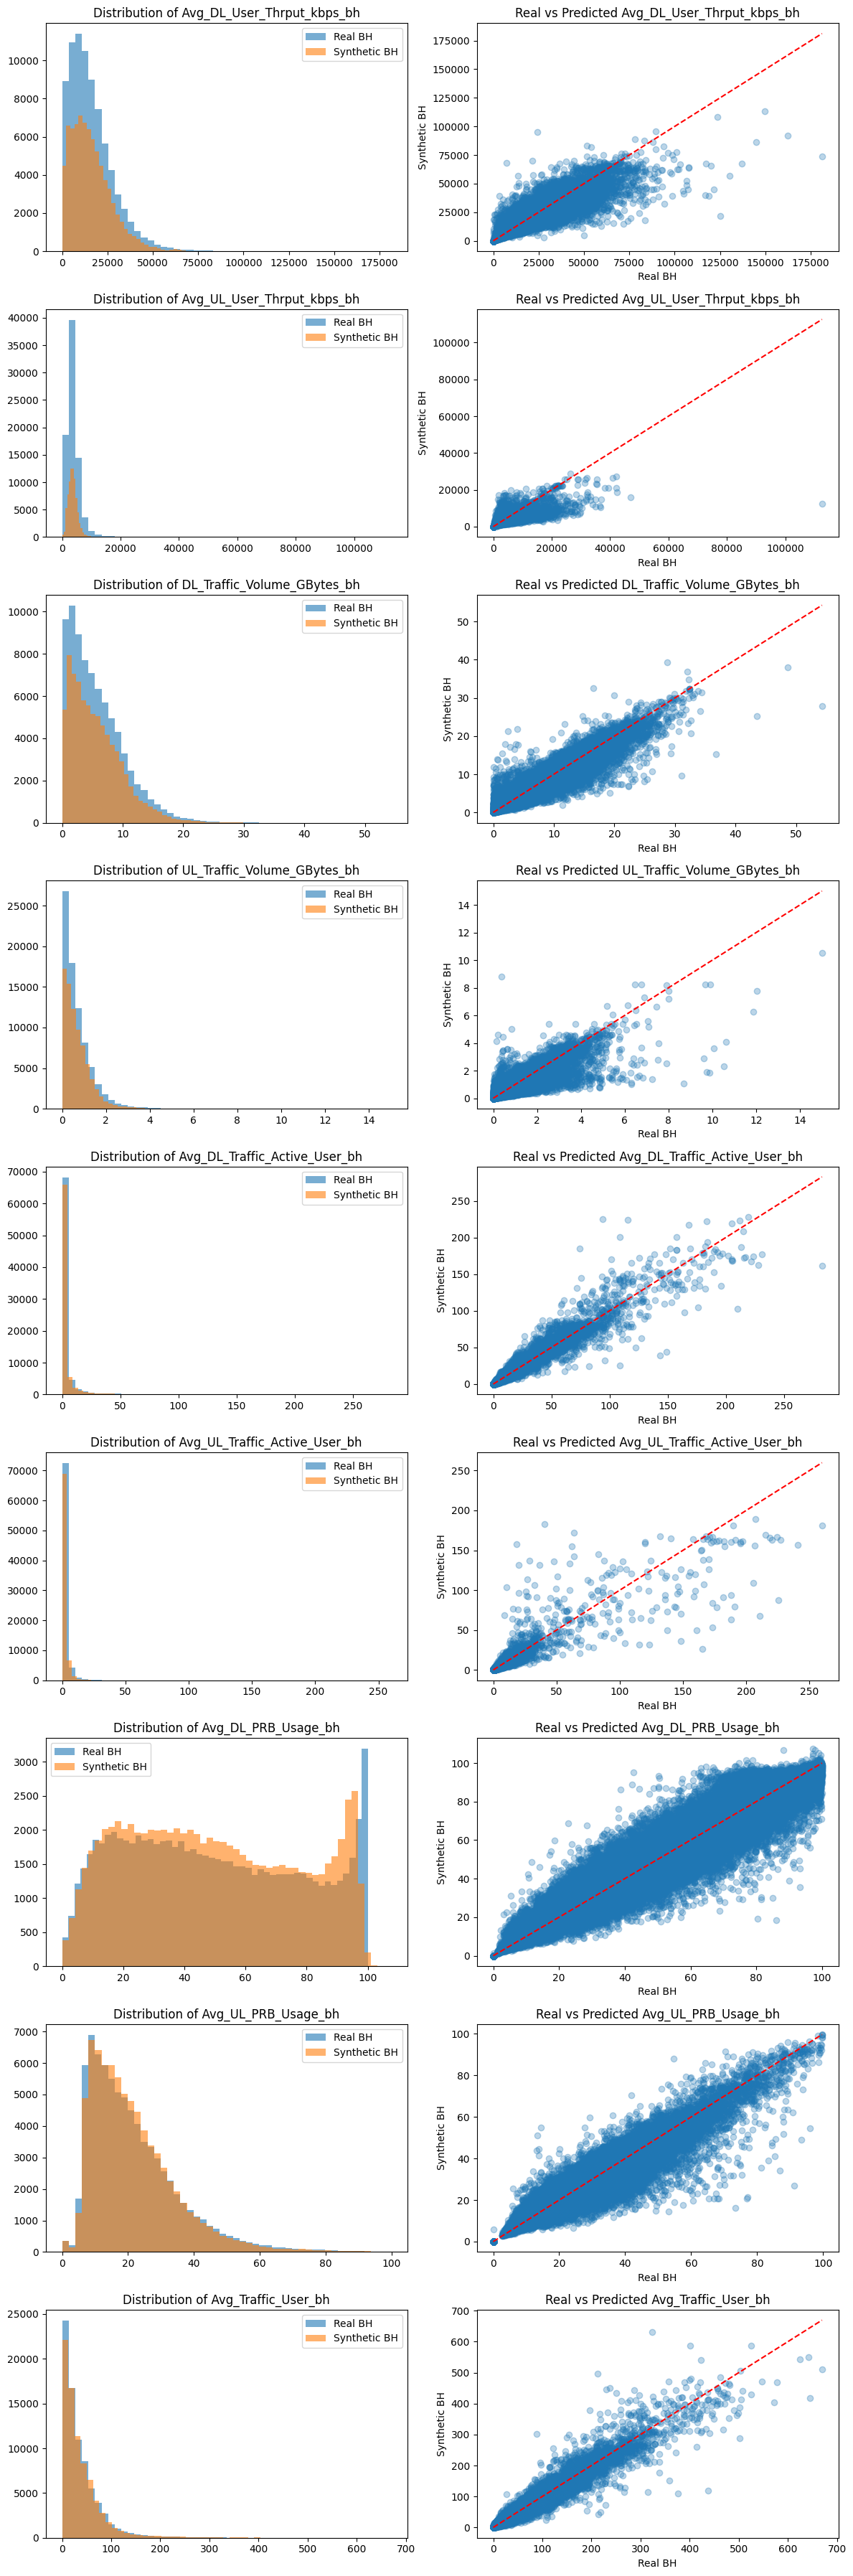

In [11]:
# Plot distributions and scatter plots for each target
fig, axes = plt.subplots(len(target_cols), 2, figsize=(12, 4*len(target_cols)))

for i, col in enumerate(target_cols):
    y_true = y_val_df[col].values
    y_pred = fitted[col].predict(X_val)
    
    # Histogram comparison: real vs synthetic BH
    axes[i,0].hist(y_true, bins=50, alpha=0.6, label="Real BH")
    axes[i,0].hist(y_pred, bins=50, alpha=0.6, label="Synthetic BH")
    axes[i,0].set_title(f"Distribution of {col}")
    axes[i,0].legend()
    
    # Scatter plot: one-to-one line
    axes[i,1].scatter(y_true, y_pred, alpha=0.3)
    axes[i,1].plot([y_true.min(), y_true.max()],
                   [y_true.min(), y_true.max()], 'r--')
    axes[i,1].set_title(f"Real vs Predicted {col}")
    axes[i,1].set_xlabel("Real BH")
    axes[i,1].set_ylabel("Synthetic BH")

plt.tight_layout()
plt.show()

In [12]:
from xgboost import XGBRegressor

# ------------------ XGBoost config (Tweedie for all) ------------------
xgb_params = dict(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:tweedie",
    tweedie_variance_power=1.2,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    eval_metric="rmse",
)

fitted_xgb = {}
metrics_mae_xgb, metrics_rmse_xgb, metrics_r2_xgb = {}, {}, {}

# ------------------ Train per target (XGBoost) ------------------
for col in target_cols:
    ytr = y_train_df[col].values
    yva = y_val_df[col].values

    model = XGBRegressor(**xgb_params)
    model.fit(X_train, ytr)

    fitted_xgb[col] = model

    # validation predictions
    yhat = model.predict(X_val)
    metrics_mae_xgb[col]  = float(mean_absolute_error(yva, yhat))
    metrics_rmse_xgb[col] = float(np.sqrt(mean_squared_error(yva, yhat)))
    metrics_r2_xgb[col]   = float(r2_score(yva, yhat))

# ------------------ Summary ------------------
print("\n=== Validation (XGBoost, Tweedie, no early stopping) ===")
print("Mean MAE:",  float(np.mean(list(metrics_mae_xgb.values()))))
print("Mean RMSE:", float(np.mean(list(metrics_rmse_xgb.values()))))
print("Mean R²:",   float(np.mean(list(metrics_r2_xgb.values()))))
print("Sample MAE:",  dict(list(metrics_mae_xgb.items())[:5]))
print("Sample RMSE:", dict(list(metrics_rmse_xgb.items())[:5]))
print("Sample R²:",   dict(list(metrics_r2_xgb.items())[:5]))


=== Validation (XGBoost, Tweedie, no early stopping) ===
Mean MAE: 417.5445362197028
Mean RMSE: 722.9511325736081
Mean R²: 0.8312622308731079
Sample MAE: {'Avg_DL_User_Thrput_kbps_bh': 2763.52197265625, 'Avg_UL_User_Thrput_kbps_bh': 978.4525146484375, 'DL_Traffic_Volume_GBytes_bh': 0.9375510215759277, 'UL_Traffic_Volume_GBytes_bh': 0.18037009239196777, 'Avg_DL_Traffic_Active_User_bh': 0.7150062322616577}
Sample RMSE: {'Avg_DL_User_Thrput_kbps_bh': 4755.114299362319, 'Avg_UL_User_Thrput_kbps_bh': 1721.4912140350878, 'DL_Traffic_Volume_GBytes_bh': 1.4457986374941891, 'UL_Traffic_Volume_GBytes_bh': 0.32708900253379974, 'Avg_DL_Traffic_Active_User_bh': 3.0148192599197237}
Sample R²: {'Avg_DL_User_Thrput_kbps_bh': 0.8440395593643188, 'Avg_UL_User_Thrput_kbps_bh': 0.47670912742614746, 'DL_Traffic_Volume_GBytes_bh': 0.8991234302520752, 'UL_Traffic_Volume_GBytes_bh': 0.7713050246238708, 'Avg_DL_Traffic_Active_User_bh': 0.9344606399536133}


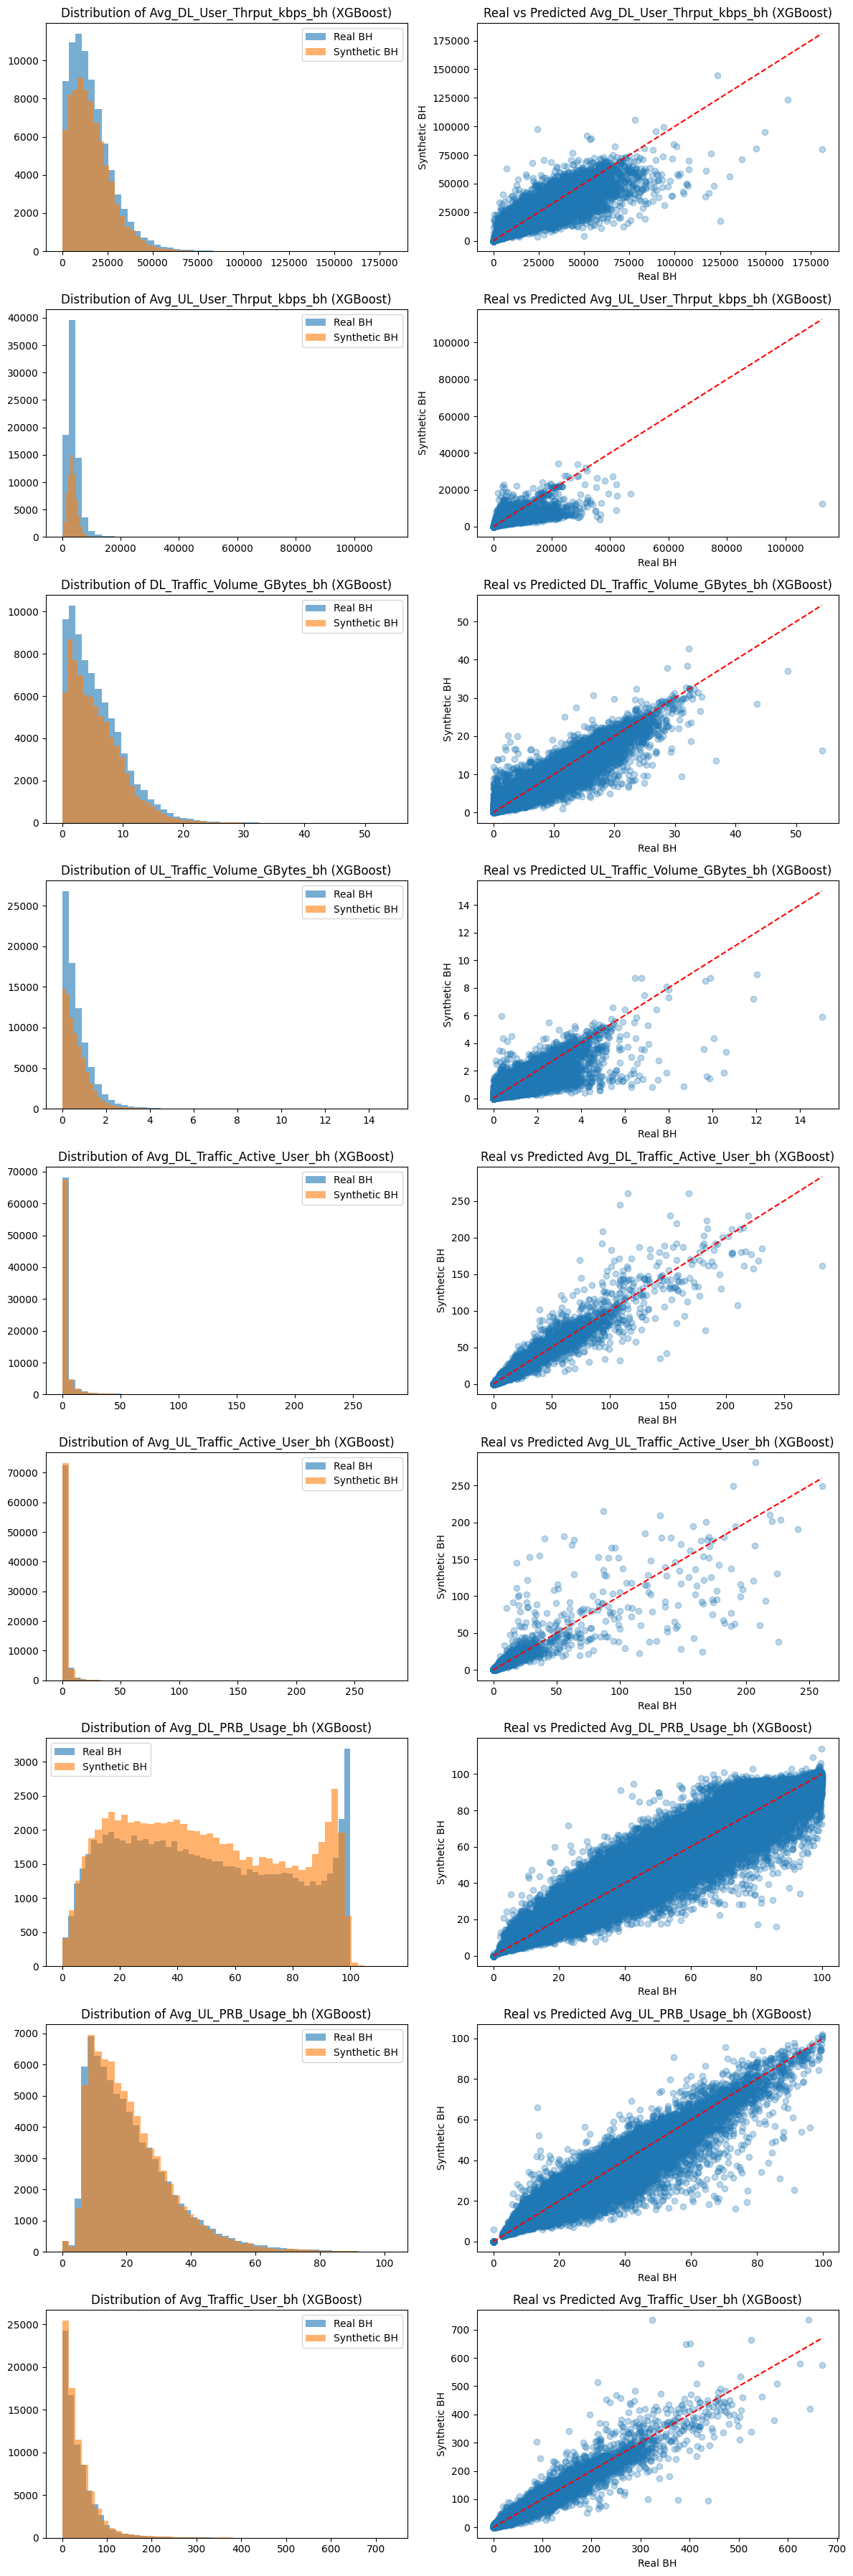

In [13]:
# ------------------ Plot distributions & scatter plots (XGBoost) ------------------
fig, axes = plt.subplots(len(target_cols), 2, figsize=(12, 4 * len(target_cols)))

for i, col in enumerate(target_cols):
    y_true = y_val_df[col].values
    y_pred = fitted_xgb[col].predict(X_val)
    
    # Histogram comparison: true vs predicted
    axes[i, 0].hist(y_true, bins=50, alpha=0.6, label="Real BH")
    axes[i, 0].hist(y_pred, bins=50, alpha=0.6, label="Synthetic BH")
    axes[i, 0].set_title(f"Distribution of {col} (XGBoost)")
    axes[i, 0].legend()
    
    # Scatter plot: one-to-one line
    axes[i, 1].scatter(y_true, y_pred, alpha=0.3)
    axes[i, 1].plot([y_true.min(), y_true.max()],
                    [y_true.min(), y_true.max()], 'r--')
    axes[i, 1].set_title(f"Real vs Predicted {col} (XGBoost)")
    axes[i, 1].set_xlabel("Real BH")
    axes[i, 1].set_ylabel("Synthetic BH")

plt.tight_layout()
plt.show()

### Applying to the 5 remaining months

In [14]:
import pandas as pd
import numpy as np

# --- config & assumptions ---
KEYS = ["Date", "Cell_Name", "LocalCell_Id"]   # your id columns

# 0) Normalize dates
df1 = df1.copy(); df2 = df2.copy()
df1["Date"] = pd.to_datetime(df1["Date"]).dt.normalize()
df2["Date"] = pd.to_datetime(df2["Date"]).dt.normalize()

# 1) Exact-key anti-join: keep only Daily rows that are NOT already present in real BH
daily_keys = df1[KEYS].drop_duplicates()
bh_keys    = df2[KEYS].drop_duplicates()

need_synth_keys = (
    daily_keys
    .merge(bh_keys.assign(_in_bh=1), on=KEYS, how="left")
    .loc[lambda d: d["_in_bh"].isna(), KEYS]
)

# 2) Pull full Daily rows for those keys (these will become synthetic BH)
daily_future = df1.merge(need_synth_keys, on=KEYS, how="inner")

# 3) Build the feature matrix for those days, matching training names (*_daily)
base_daily_cols = [c.replace("_daily", "") for c in feature_cols]
missing = [c for c in base_daily_cols if c not in daily_future.columns]
if missing:
    raise KeyError(f"These Daily KPIs needed for features are missing: {missing}")

X_future = daily_future[base_daily_cols].copy()
X_future.columns = feature_cols  # rename to *_daily to match training
X_future = X_future.astype("float32")

# 4) Impute with TRAIN medians
train_meds = X_train.median(numeric_only=True)
X_future = X_future.fillna(train_meds)

# 5) Predict BH KPIs with your trained XGBoost models
models = fitted_xgb
preds = {col: models[col].predict(X_future).astype(np.float32) for col in target_cols}

# 6) Assemble the synthetic BH dataframe
synthetic_bh = daily_future[KEYS].copy()
for col in target_cols:
    synthetic_bh[col] = preds[col]

# Keep useful meta columns from Daily
meta_keep = ["eNodeB_Name","Frequency_band","Cell_FDD_TDD_Indication",
             "eNodeB_Function_Name","Integrity"]
for m in meta_keep:
    if m in daily_future.columns:
        synthetic_bh[m] = daily_future[m].values

synthetic_bh = synthetic_bh.sort_values(KEYS).reset_index(drop=True)
print("Synthetic BH rows:", synthetic_bh.shape)

Synthetic BH rows: (1939940, 17)


In [15]:
KEYS = ["Date", "Cell_Name", "LocalCell_Id"]

# The 9 BH targets in the final 6-month dataset
target_cols = [
    "Avg_DL_User_Thrput_kbps_bh",
    "Avg_UL_User_Thrput_kbps_bh",
    "DL_Traffic_Volume_GBytes_bh",
    "UL_Traffic_Volume_GBytes_bh",
    "Avg_DL_Traffic_Active_User_bh",
    "Avg_UL_Traffic_Active_User_bh",
    "Avg_DL_PRB_Usage_bh",
    "Avg_UL_PRB_Usage_bh",
    "Avg_Traffic_User_bh",
]

def _resolve_real_bh_name_map(df_real: pd.DataFrame, desired_targets):
    """
    For each desired *_bh target, find the column name present in df_real and
    build a mapping {present_name -> desired_name}. Tries no-suffix and GByte/GBytes variants.
    """
    name_map = {}
    for tgt in desired_targets:
        base = tgt[:-3] if tgt.endswith("_bh") else tgt
        candidates = [
            tgt,
            base,
            base.replace("GBytes", "GByte"),
            base.replace("GByte", "GBytes"),
        ]
        found = None
        for cand in candidates:
            if cand in df_real.columns:
                found = cand
                break
        if not found:
            raise KeyError(f"Couldn’t find a matching column in real BH for target '{tgt}'. "
                           f"Tried: {candidates}")
        name_map[found] = tgt
    return name_map

# 1) Normalize dates
df2 = df2.copy()
synthetic_bh = synthetic_bh.copy()
df2["Date"] = pd.to_datetime(df2["Date"]).dt.normalize()
synthetic_bh["Date"] = pd.to_datetime(synthetic_bh["Date"]).dt.normalize()

# 2) Build rename map and align real BH columns to *_bh names
rename_map = _resolve_real_bh_name_map(df2, target_cols)
print("Real BH rename map:", rename_map)

real_bh = df2[KEYS + list(rename_map.keys())].rename(columns=rename_map)

# 3) Ensure synthetic has the desired targets
missing_in_synth = [c for c in target_cols if c not in synthetic_bh.columns]
if missing_in_synth:
    raise KeyError(f"These target cols are missing in synthetic_bh: {missing_in_synth}")

synth_bh = synthetic_bh[KEYS + target_cols].copy()

# 4) Concatenate and sort
bh_full = pd.concat([real_bh, synth_bh], axis=0, ignore_index=True)
bh_full = bh_full.sort_values(KEYS).reset_index(drop=True)

print("Final 6-month BH dataset:", bh_full.shape)
bh_full.head()

Real BH rename map: {'Avg_DL_User_Thrput_kbps': 'Avg_DL_User_Thrput_kbps_bh', 'Avg_UL_User_Thrput_kbps': 'Avg_UL_User_Thrput_kbps_bh', 'DL_Traffic_Volume_GBytes': 'DL_Traffic_Volume_GBytes_bh', 'UL_Traffic_Volume_GBytes': 'UL_Traffic_Volume_GBytes_bh', 'Avg_DL_Traffic_Active_User': 'Avg_DL_Traffic_Active_User_bh', 'Avg_UL_Traffic_Active_User': 'Avg_UL_Traffic_Active_User_bh', 'Avg_DL_PRB_Usage': 'Avg_DL_PRB_Usage_bh', 'Avg_UL_PRB_Usage': 'Avg_UL_PRB_Usage_bh', 'Avg_Traffic_User': 'Avg_Traffic_User_bh'}
Final 6-month BH dataset: (2345139, 12)


,Date,Cell_Name,LocalCell_Id,Avg_DL_User_Thrput_kbps_bh,Avg_UL_User_Thrput_kbps_bh,DL_Traffic_Volume_GBytes_bh,UL_Traffic_Volume_GBytes_bh,Avg_DL_Traffic_Active_User_bh,Avg_UL_Traffic_Active_User_bh,Avg_DL_PRB_Usage_bh,Avg_UL_PRB_Usage_bh,Avg_Traffic_User_bh
0,2025-02-13,0001_KKO_KATI_1_L1800,4,13520.391602,3716.757080,4.948938,0.503135,1.261713,1.482398,52.442558,17.163996,30.425196
1,2025-02-13,0001_KKO_KATI_1_L2600,81,16232.486328,4333.121582,6.513429,0.719300,1.520984,1.812863,48.620041,21.771940,56.327065
2,2025-02-13,0001_KKO_KATI_1_L800,11,8281.962891,3409.614746,1.373910,0.223069,0.993890,0.847493,38.122795,10.562400,14.860570
3,2025-02-13,0001_KKO_KATI_2S_L1800,15,7634.928223,3509.450195,7.821651,0.834933,2.834707,2.453291,79.811554,26.919975,48.691872
4,2025-02-13,0001_KKO_KATI_2S_L2600,85,13897.337891,5098.342285,7.327261,0.851808,1.628299,1.470784,59.453506,19.292503,42.984936


In [16]:
bh_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345139 entries, 0 to 2345138
Data columns (total 12 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   Date                           datetime64[ns]
 1   Cell_Name                      string        
 2   LocalCell_Id                   string        
 3   Avg_DL_User_Thrput_kbps_bh     float64       
 4   Avg_UL_User_Thrput_kbps_bh     float64       
 5   DL_Traffic_Volume_GBytes_bh    float64       
 6   UL_Traffic_Volume_GBytes_bh    float64       
 7   Avg_DL_Traffic_Active_User_bh  float64       
 8   Avg_UL_Traffic_Active_User_bh  float64       
 9   Avg_DL_PRB_Usage_bh            float64       
 10  Avg_UL_PRB_Usage_bh            float64       
 11  Avg_Traffic_User_bh            float64       
dtypes: datetime64[ns](1), float64(9), string(2)
memory usage: 214.7 MB


In [17]:
# Check key coverage
set_daily   = set(df1["Date"].unique())
set_bh      = set(bh_full["Date"].unique())

print("Daily months:", min(set_daily), "→", max(set_daily))
print("BH months:  ", min(set_bh),    "→", max(set_bh))

# Check number of unique cells
print("Unique cells daily:", df1["Cell_Name"].nunique())
print("Unique cells bh:   ", bh_full["Cell_Name"].nunique())

Daily months: 2025-02-13 00:00:00 → 2025-08-11 00:00:00
BH months:   2025-02-13 00:00:00 → 2025-08-11 00:00:00
Unique cells daily: 13272
Unique cells bh:    13272


In [18]:
bh_full.to_csv("Huawei_synthetic_full_BH_4G.csv", index=False)